        Project On Image Recognition Using Cnn on CIFAR-10 Dataset

                           By Archi Jain



In [ ]:
from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from keras.datasets import cifar10
from keras.models import Sequential
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ---------------------------------------------------------------------------
# STEP 1: Load the dataset
# ---------------------------------------------------------------------------

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1387s 8us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

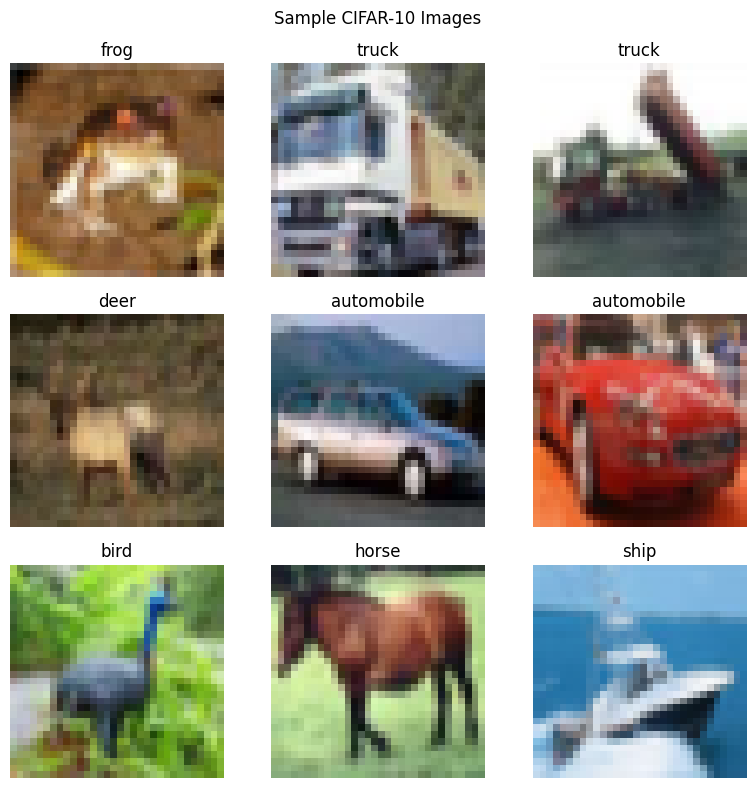

Saved sample_images.png -- open it to see example training images.


In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


# ---------------------------------------------------------------------------
# STEP 2: Look at the data before doing anything else
# ---------------------------------------------------------------------------

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()
plt.close()
print("Saved sample_images.png -- open it to see example training images.")

In [ ]:
# ---------------------------------------------------------------------------
# STEP 3: Preprocess the data
# ---------------------------------------------------------------------------
# 3a. Scale pixel values from [0, 255] down to [0, 1] (Min/Max Scaling)

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


# 3b. One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("\nAfter preprocessing:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


After preprocessing:
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)


In [ ]:
# ---------------------------------------------------------------------------
# STEP 4: Build the CNN Model
# ---------------------------------------------------------------------------

model = Sequential()

model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
# ---------------------------------------------------------------------------
# STEP 5: Data Augmentation
# ---------------------------------------------------------------------------

datagen = ImageDataGenerator(
    rotation_range=15,        # randomly rotate images by up to 15 degrees
    width_shift_range=0.1,    # randomly shift images horizontally
    height_shift_range=0.1,   # randomly shift images vertically
    horizontal_flip=True,     # randomly flip images left-right
)
datagen.fit(X_train)


# ---------------------------------------------------------------------------
# STEP 6: Train the model
# ---------------------------------------------------------------------------

BATCH_SIZE = 64
EPOCHS = 25

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 370s 473ms/step - accuracy: 0.6072 - loss: 1.1065 - val_accuracy: 0.6351 - val_loss: 1.0668
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 363s 465ms/step - accuracy: 0.6497 - loss: 0.9907 - val_accuracy: 0.6338 - val_loss: 1.0895
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 365s 466ms/step - accuracy: 0.6753 - loss: 0.9236 - val_accuracy: 0.6696 - val_loss: 0.9522
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 365s 467ms/step - accuracy: 0.6973 - loss: 0.8629 - val_accuracy: 0.7293 - val_loss: 0.7860
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 360s 460ms/step - accuracy: 0.7090 - loss: 0.8333 - val_accuracy: 0.6560 - val_loss: 1.0092
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 364s 465ms/step - accuracy: 0.7251 - loss: 0.7953 - val_accuracy: 0.7000 - val_loss: 0.8902
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 369s 472ms/step - accuracy: 0.7343 - loss: 0.7629 - val_accuracy: 0.7555 - val_loss: 0.7045
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 359s 459ms/step - accuracy: 0.7433 -

In [ ]:
# ---------------------------------------------------------------------------
# STEP 7: Evaluate the model
# ---------------------------------------------------------------------------
score = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f}")



Test Loss: 0.5290
Test Accuracy: 0.8236


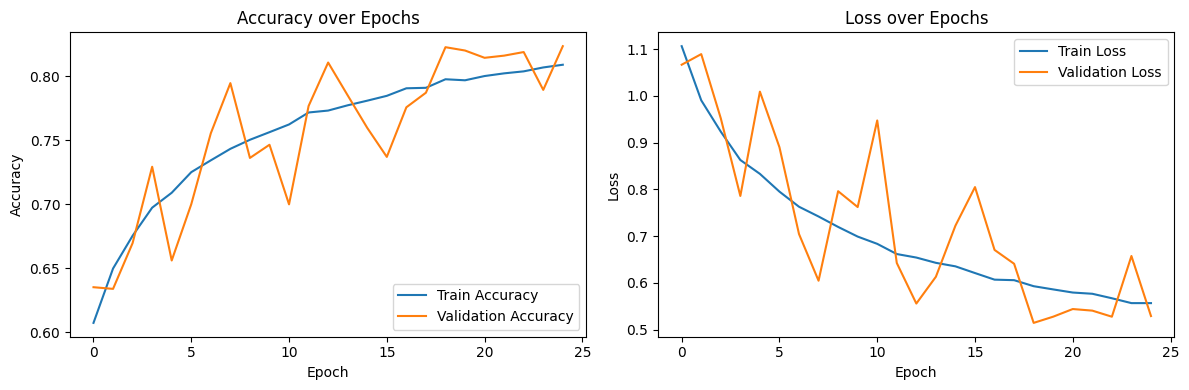

Saved training_history.png


In [ ]:
# ---------------------------------------------------------------------------
# STEP 8: Plot training history
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_history.png")
plt.show()
plt.close()
print("Saved training_history.png")


313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step


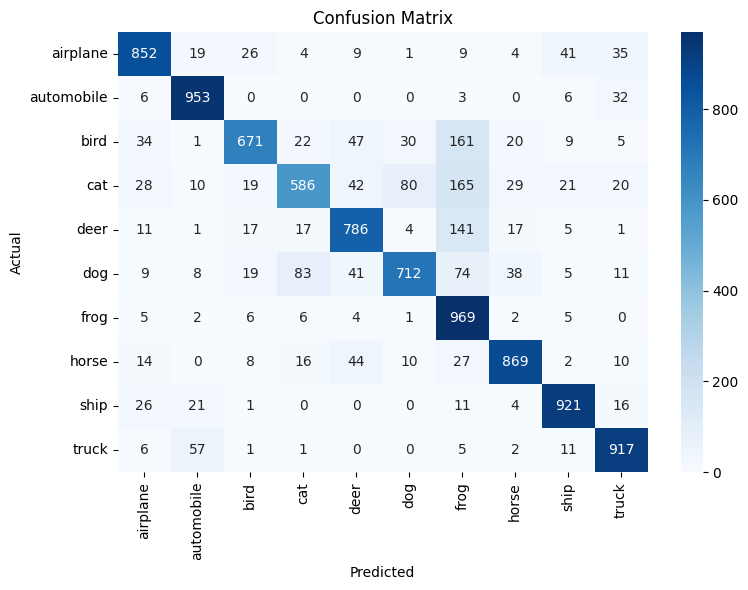

Saved confusion_matrix.png

Classification Report:
              precision    recall  f1-score   support

    airplane       0.86      0.85      0.86      1000
  automobile       0.89      0.95      0.92      1000
        bird       0.87      0.67      0.76      1000
         cat       0.80      0.59      0.68      1000
        deer       0.81      0.79      0.80      1000
         dog       0.85      0.71      0.77      1000
        frog       0.62      0.97      0.76      1000
       horse       0.88      0.87      0.88      1000
        ship       0.90      0.92      0.91      1000
       truck       0.88      0.92      0.90      1000

    accuracy                           0.82     10000
   macro avg       0.84      0.82      0.82     10000
weighted avg       0.84      0.82      0.82     10000



In [ ]:
# ---------------------------------------------------------------------------
# STEP 9: Confusion matrix -- see WHICH classes get confused with which
# ---------------------------------------------------------------------------

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()
print("Saved confusion_matrix.png")

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


In [ ]:
# ---------------------------------------------------------------------------
# STEP 10: Save the model, and show how to load + predict on new images
# ---------------------------------------------------------------------------
model.save("cifar10_cnn_model.keras")
print("\nModel saved as cifar10_cnn_model.keras")



Model saved as cifar10_cnn_model.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


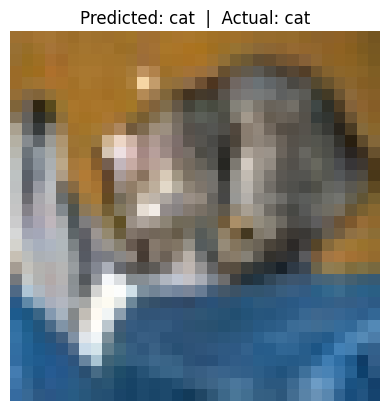

Predicted class: cat
Actual class: cat
Confidence: 94.08931 %


In [ ]:
# ---------------------------------------------------------------------------
# Running Example
# ---------------------------------------------------------------------------

from tensorflow.keras.models import load_model
loaded_model = load_model("cifar10_cnn_model.keras")

# Pick which test image to check (change the index to look at different images)
index = 0

# Show the image
plt.imshow(X_test[index])
plt.axis("off")

# Get the model's prediction for that same image
prediction = loaded_model.predict(X_test[index:index+1])
predicted_class = class_names[np.argmax(prediction)]

# Get the TRUE label for comparison (this is the piece your original code was missing)
true_class = class_names[np.argmax(y_test[index])]

plt.title(f"Predicted: {predicted_class}  |  Actual: {true_class}")
plt.show()

print("Predicted class:", predicted_class)
print("Actual class:", true_class)
print("Confidence:", np.max(prediction) * 100, "%")